## Convolutional neural networks

## Imports y carga de datos

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import os
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

warnings.simplefilter(action="ignore", category=FutureWarning)

# Reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Carga de datos
start_date = '1945-01-01'
tickers_validos = ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD',
                   'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM',
                   'MO', 'MRK', 'MSI', 'PG', 'XOM']

precios_close = yf.download(tickers_validos, start=start_date,
                            auto_adjust=True, progress=False)['Close']
precios_close.dropna(axis=1, inplace=True)

returns = np.log(precios_close).diff().dropna()
print(f"Returns: {returns.shape}")

Returns: (16197, 23)


## Funciones auxiliares 

In [2]:
def create_time_series_data(data, input_window_size, output_window_size):
    X, y = [], []
    data_array = data.values if isinstance(data, pd.DataFrame) else data
    for i in range(len(data_array) - input_window_size - output_window_size + 1):
        input_seq = data_array[i : i + input_window_size]
        output_seq = data_array[i + input_window_size : i + input_window_size + output_window_size]
        X.append(input_seq)
        y.append(np.mean(output_seq, axis=0))
    return np.array(X), np.array(y)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def split_triple(X, y, test_size=0.1, val_size=0.05):
    """Triple split cronológico (sin shuffle en test, con shuffle en val)."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, shuffle=True
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

## Callback

In [3]:
from tensorflow.keras.callbacks import Callback
from sklearn.preprocessing import StandardScaler

class MAERealCallback(Callback):
    """
    Calcula MAE en escala original tras des-normalizar con scaler_y.
    Necesario porque el modelo entrena con datos normalizados y el loss
    interno de Keras está en escala normalizada.
    """
    def __init__(self, X_train_n, y_train_real, X_val_n, y_val_real, scaler_y):
        super().__init__()
        self.X_train_n = X_train_n
        self.y_train_real = y_train_real
        self.X_val_n = X_val_n
        self.y_val_real = y_val_real
        self.scaler_y = scaler_y
        self.mae_train = []
        self.mae_val = []

    def on_epoch_end(self, epoch, logs=None):
        pred_train = self.scaler_y.inverse_transform(
            self.model.predict(self.X_train_n, verbose=0))
        pred_val = self.scaler_y.inverse_transform(
            self.model.predict(self.X_val_n, verbose=0))

        self.mae_train.append(np.mean(np.abs(self.y_train_real - pred_train)))
        self.mae_val.append(np.mean(np.abs(self.y_val_real - pred_val)))

## Comenzamos con las combinaciones

In [4]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

resultados = []
historiales = {}

### 1. Combinación input window 5

Para la ventana de 5 días tendrá más sentido que las ventanas que recoge la cnn sean de menos días que cuando aumentemos. Inicialmente pruebo con 5, que es que no se mueva el filtro, luego voy bajando a 3 y luego acabo en 2.

También las neuronas que requerirá una secuencia de 5 días son filtros mucho más pequeños, por lo que empezamos con modelos mucho más pequeños que en las siguientes situaciones.

No podemos hacer poolings, solo dejamos el del final, porque nos quedamos sin dimensiones en los días.

#### 1.1 Combinación input window 5, salida 1

In [ ]:
# Definimos los datos de train, validación y test para el primer experimento
X, y = create_time_series_data(returns, 5, 1)
X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

# Normalizamos solo con los datos de entrenamiento
scaler_X = StandardScaler()
scaler_X.fit(X_train.reshape(-1, X_train.shape[-1]))

scaler_y = StandardScaler()
scaler_y.fit(y_train)

# Transformamos X manteniendo la estructura para CNN
X_train_n = scaler_X.transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_val_n = scaler_X.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test_n = scaler_X.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

# Transformamos y
y_train_n = scaler_y.transform(y_train)
y_val_n = scaler_y.transform(y_val)
y_test_n = scaler_y.transform(y_test)




In [ ]:
# Construcción del modelo CNN
modelo = Sequential()

modelo = models.Sequential([
    # Capa 1: Conv -> ReLU
    layers.Conv1D(filters=4, kernel_size=3, input_shape=(X_train_n.shape[1], X_train_n.shape[2]),   
                  padding='same', activation='relu'),
    # Capa 2: Conv -> ReLU
    layers.Conv1D(filters=4, kernel_size=3,   
                  padding='same', activation='relu'),

    # Final: GAP -> Dense -> Output
    layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.1),
    layers.Dense(y_train_n.shape[1])
])

optimizador = tf.keras.optimizers.Adam(learning_rate=0.001)

modelo.compile(optimizer=optimizador, loss='mae')

mae_real_cb = MAERealCallback(
    X_train_n,
    y_train,
    X_val_n,
    y_val,
    scaler_y
)

print("Entrenando al lobo de Wall Street")
historia = modelo.fit(X_train_n, y_train_n, epochs=400, batch_size=32, validation_data=(X_val_n, y_val_n), verbose=1, callbacks=[mae_real_cb])

modelo.summary()

Entrenando al lobo de Wall Street
Epoch 1/200


c:\Users\Miriamdbg\anaconda3\envs\entorno_rnn\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


433/433 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6939 - val_loss: 0.6799
Epoch 2/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6913 - val_loss: 0.6794
Epoch 3/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6910 - val_loss: 0.6794
Epoch 4/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6909 - val_loss: 0.6793
Epoch 5/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6908 - val_loss: 0.6793
Epoch 6/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6908 - val_loss: 0.6793
Epoch 7/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6908 - val_loss: 0.6793
Epoch 8/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.6908 - val_loss: 0.6793
Epoch 9/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6908 - val_loss: 0.6794
Epoch 10/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6907 - val_loss: 0.6794
Epoch 11/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.6907 - val_loss: 0.6795
Epoch 12/200
433/433 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

KeyboardInterrupt: 

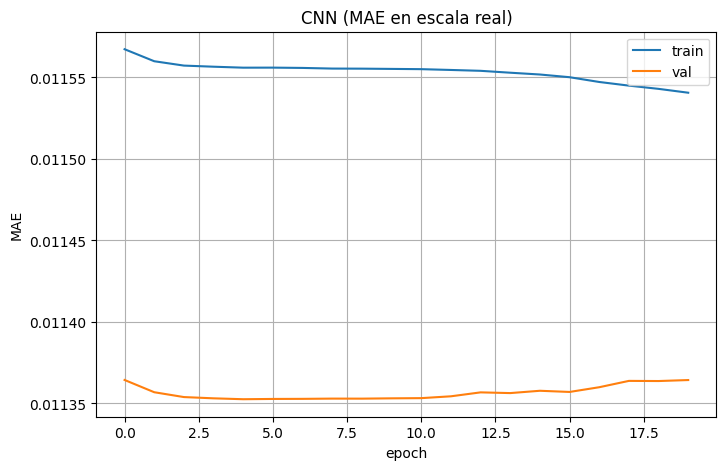

In [ ]:
# Gráfica de pérdida

plt.figure(figsize=(8, 5))

plt.plot(mae_real_cb.mae_train, label="train")
plt.plot(mae_real_cb.mae_val, label="val")

plt.xlabel("epoch")
plt.ylabel("MAE")
plt.title("CNN (MAE en escala real)")

plt.legend()
plt.grid(True)

plt.show()